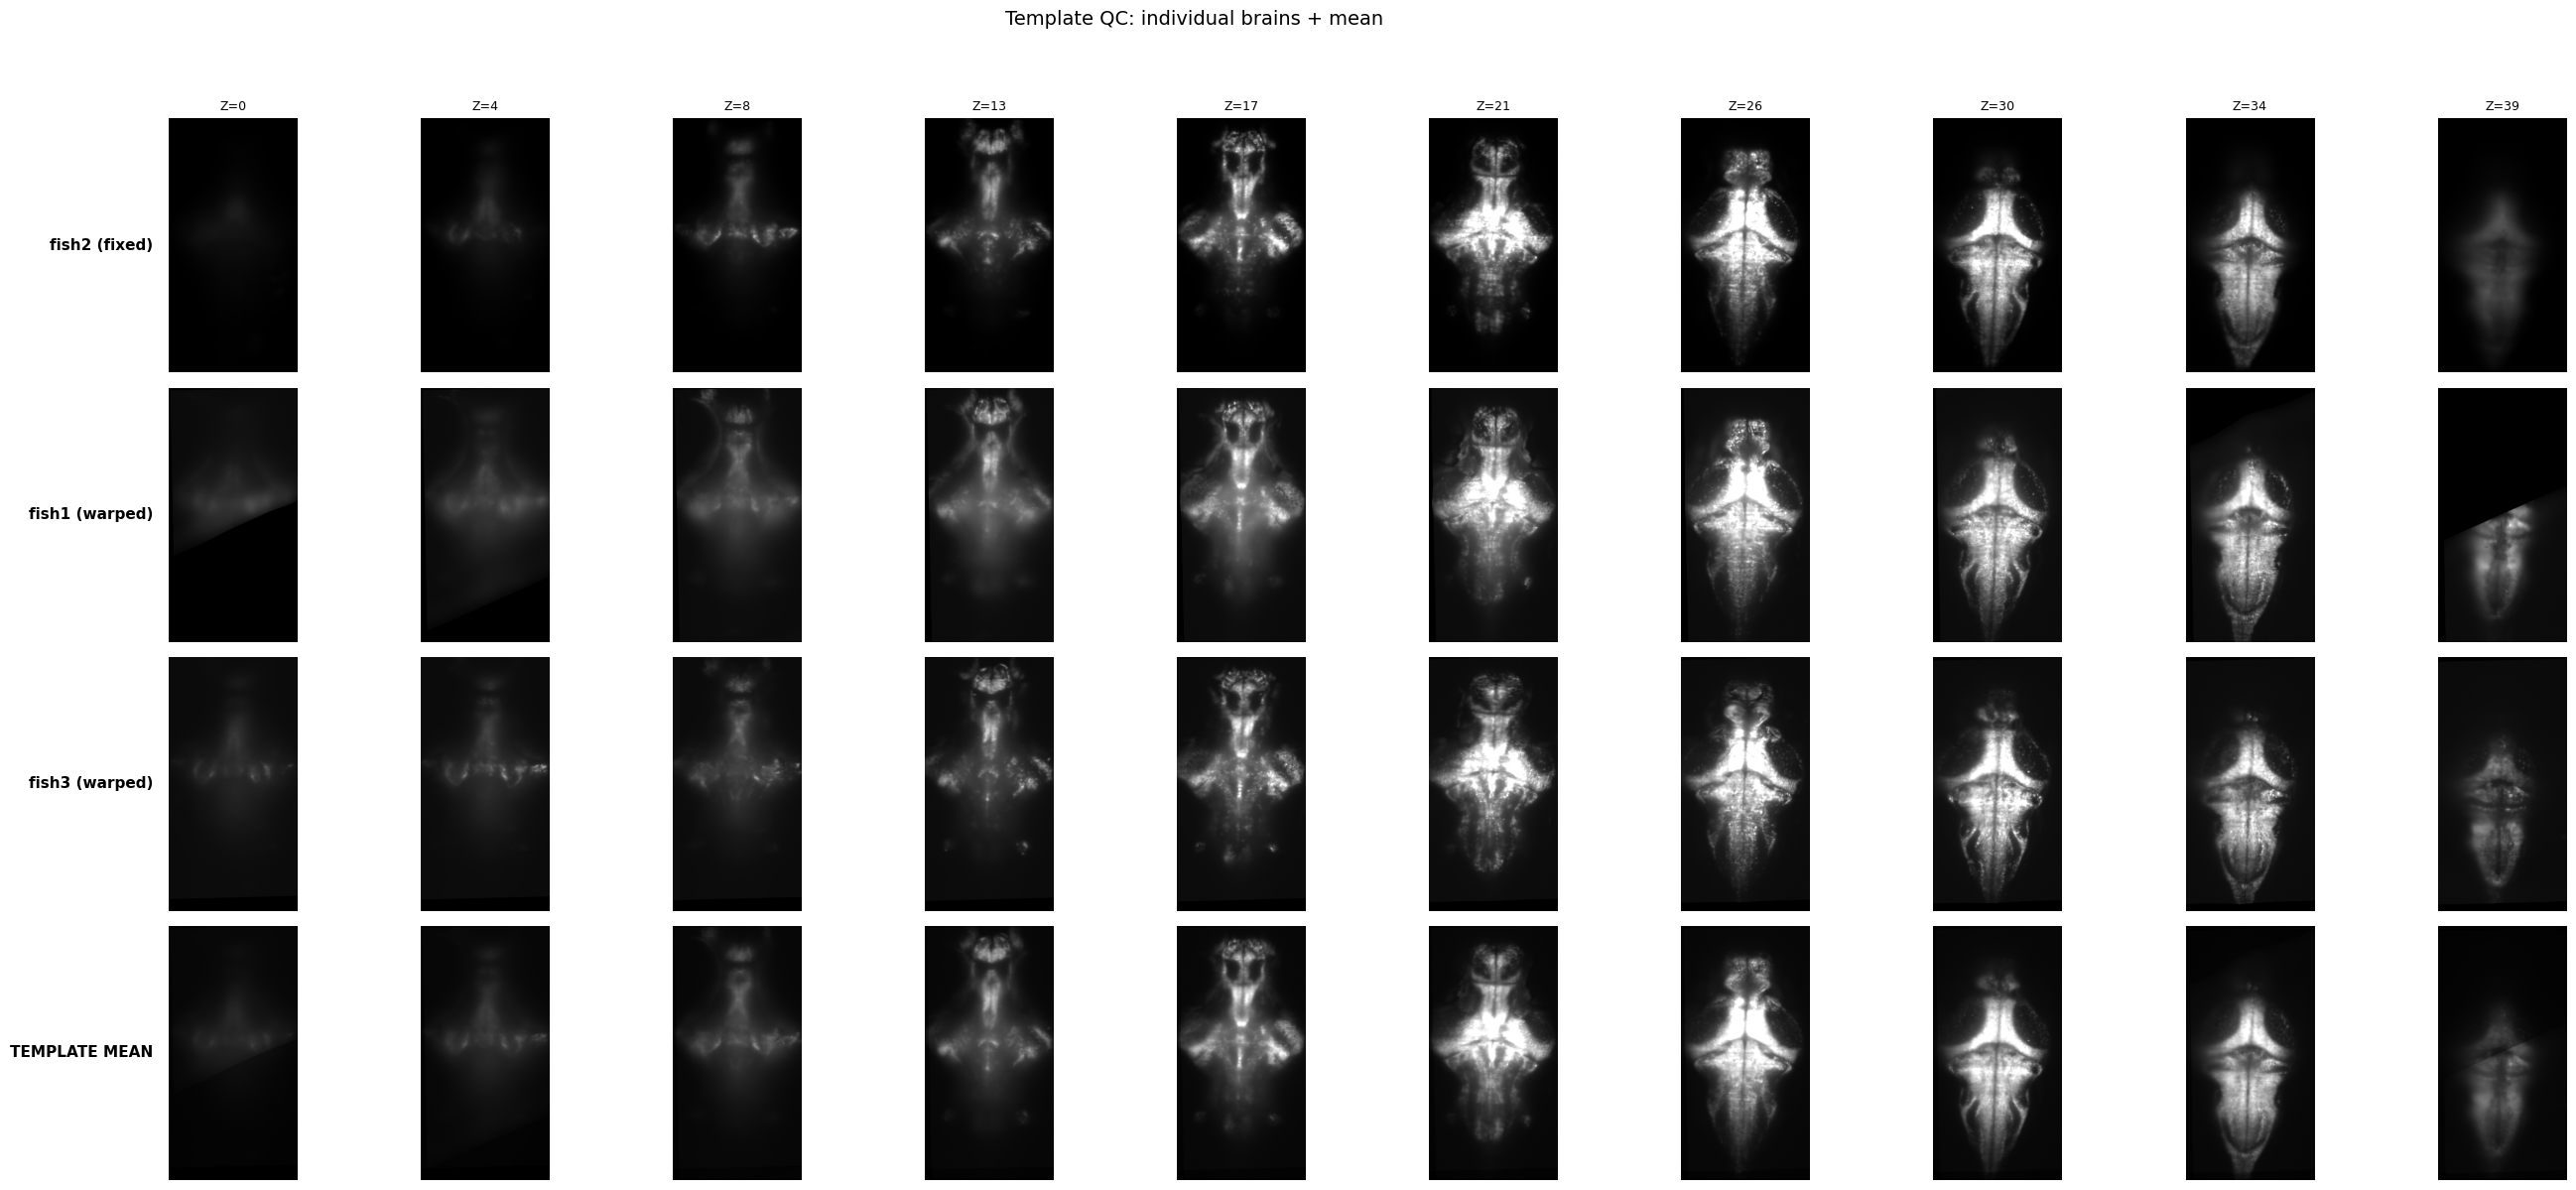

In [13]:
import ants
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE = Path(
    "/resnick/groups/Proberlab/yun/lightsheet/"
    "hcrt-trpv1_huc-h2b-g8m_csn_120min_audio/zstack_template"
)

template = ants.image_read(str(BASE / "template_mean_brain.nii.gz"))
fixed    = ants.image_read(str(BASE / "fish2_fixed.nii.gz"))
fish1_w  = ants.image_read(str(BASE / "fish1" / "fish1_registered_final.nii.gz"))
fish3_w  = ants.image_read(str(BASE / "fish3" / "fish3_registered_final.nii.gz"))

brains = {
    "fish2 (fixed)": fixed,
    "fish1 (warped)": fish1_w,
    "fish3 (warped)": fish3_w,
    "TEMPLATE MEAN": template,
}

n_z = template.shape[2]
z_slices = np.linspace(0, n_z - 1, 10, dtype=int)

fig, axes = plt.subplots(
    len(brains),
    len(z_slices),
    figsize=(3 * len(z_slices), 3 * len(brains)),
)

for row, (label, brain) in enumerate(brains.items()):
    vol = brain.numpy()
    vmin, vmax = np.percentile(vol, [1, 99])

    for col, z in enumerate(z_slices):
        ax = axes[row, col]

        ax.imshow(
            vol[:, :, z].T,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            origin="lower",
        )

        ax.invert_yaxis()
        ax.axis("off")

        if row == 0:
            ax.set_title(f"Z={z}", fontsize=9)

        # Row title on the left
        if col == 0:
            ax.text(
                -0.12,
                0.5,
                label,
                transform=ax.transAxes,
                fontsize=11,
                fontweight="bold",
                ha="right",
                va="center",
                clip_on=False,
            )

fig.suptitle(
    "Template QC: individual brains + mean",
    fontsize=14,
    y=0.995,
)

# Leave extra space on the left for row labels
plt.tight_layout(rect=[0.08, 0, 1, 0.96])

output_path = BASE / "template_qc_all_brains.pdf"
plt.savefig(
    output_path,
    dpi=150,
    bbox_inches="tight",
)
plt.show()

In [2]:
 print(template.spacing)

(1.5199999809265137, 1.5199999809265137, 7.5)
